In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,r2_score

In [10]:
# Loading the dataset
df = pd.read_csv("data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
# Basic data info
print(f"Shape: {df.shape}")
print(f"\nColumn datatypes: \n{df.dtypes}")
print(f"\nMissing Values \n{df.isnull().sum()}")
print(f"\nDuplicate Values {df.duplicated().sum()}")

Shape: (1338, 7)

Column datatypes: 
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Values 1


In [23]:
# Dropping Duplicate Records
df.drop_duplicates(keep="first", inplace=True)
print(f"\nDuplicate Values {df.duplicated().sum()}")


Duplicate Values 0


#### Data Visualization (EDA)

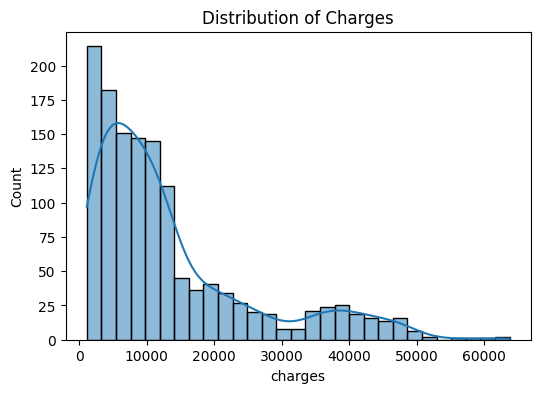

In [26]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(df["charges"],kde=True)
plt.title("Distribution of Charges")
plt.show()

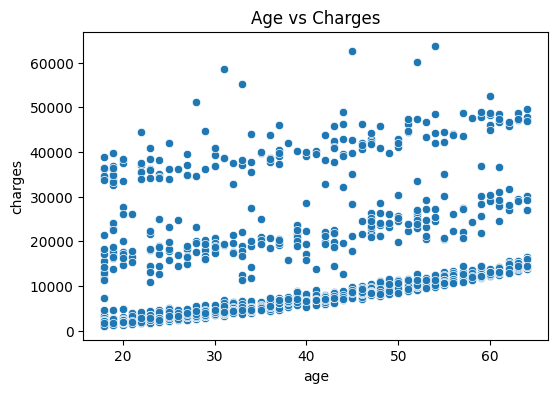

In [27]:
# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x="age",y="charges",data=df)
plt.title("Age vs Charges")
plt.show()

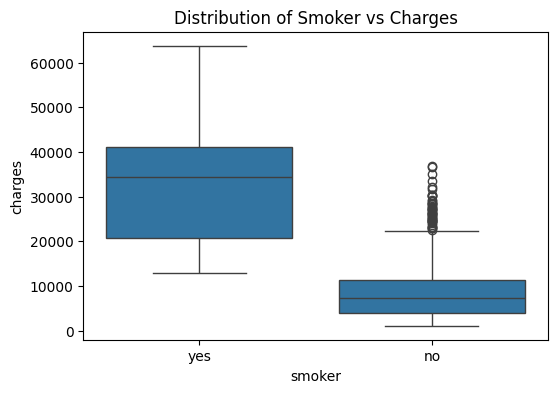

In [28]:
# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker",y="charges",data=df)
plt.title("Distribution of Smoker vs Charges")
plt.show()

In [31]:
def detect_outliers_iqr(new_df,column):
    q1 = new_df[column].quantile(0.25)
    q3 = new_df[column].quantile(0.75)
    iqr = q3 - q1
    lb = q1-1.5*iqr
    ub = q3 + 1.5*iqr
    outliers = new_df[(new_df[column] < ub) | (new_df[column] > lb)]
    print(f"Lower bound: {lb}, Upper bound: {ub}")
    return lower_bound,upper_bound

lower_bound,upper_bound = detect_outliers_iqr(df,"charges")

Lower bound: -13120.716174999998, Upper bound: 34524.777625


In [34]:
df_no_outliers = df[(df["charges"]>=lower_bound) & (df["charges"]<=upper_bound)]
print(f"Dataset after removing outliers {df_no_outliers.shape}")

Dataset after removing outliers (1198, 7)


In [39]:
df["log_charges"] = np.log(df["charges"])
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


In [40]:
# Features and Target Selection
x = df.drop(["charges","log_charges"], axis=1)
y = df["log_charges"]

#### Encoding and Scaling

In [57]:
numerical_features = ["age","bmi","children"]
categorical_features = ["sex","smoker","region"]

numeric_transformation = StandardScaler()
categorical_transformation = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(transformers=[("num",numeric_transformation,numerical_features),("cat",categorical_transformation,categorical_features)])

#### Train Test Split

In [58]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(f"Train.shape: {X_train.shape}")
print(f"Test.shape: {X_test.shape}")

Train.shape: (1069, 6)
Test.shape: (268, 6)


#### Model Trainning

In [59]:
lr_pipeline = Pipeline(steps=[("preprocessor",preprocessor),("model",LinearRegression())])
lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Model Evaluation

In [65]:
y_pred = lr_pipeline.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"RMSE: {np.sqrt(mean_absolute_error(y_test,y_pred))}")
print(f"R2 Score: {r2_score(y_test,y_pred)}")

MAE: 0.26070175352875474
MAE: 0.26070175352875474
RMSE: 0.510589613612297
R2 Score: 0.8294642959644737
